In [5]:
import cairosvg
import io
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
import random
import rdkit
import sys
from rdkit import Chem
from rdkit import RDConfig
from rdkit.Chem import Draw
from rdkit.Chem import QED
from rdkit.Chem import rdFMCS
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem.Draw import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.DataManip.Metric import GetTanimotoDistMat
from rdkit.DataManip.Metric import GetTanimotoSimMat
from IPython.display import Image, display
import tools
from tools import Results
from glob import glob
from matplotlib.ticker import FuncFormatter

%load_ext autoreload
%autoreload 2

IPythonConsole.ipython_useSVG=True
sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
import sascorer
print(rdkit.__version__)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
2025.09.5


[0.61328125, 0.46875, 0.45703125, 0.3515625, 0.14453125, 0.1015625, 0.15234375, 0.05078125]


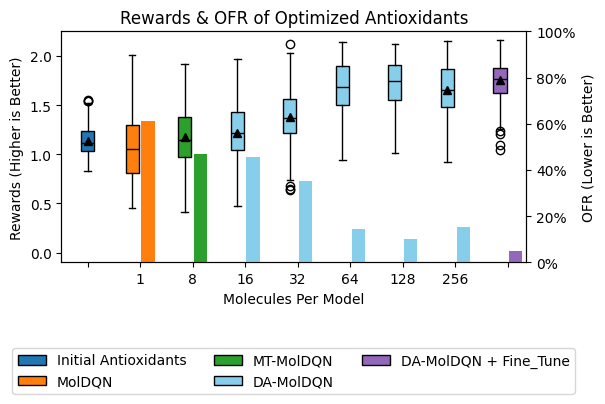

In [32]:
from tools import Results

average_episodes = 1
max_bde = 76
min_ip = 145

exp_path = '../Experiments'
text = ['Initial Rewards', 'individual', '8 mols','16 mols','32 mols', '64 mols', '128 mols', '256 mols', 'Fine Tune']
trials = [600, 2200, 2100, 2300, 2400, 2800, 2900, 573200] # 2200 is before 2100
rewards = [Results(f'{exp_path}/trial_{t}.pickle') for t in trials]
initial_rewards = [rewards[-2][p] for p in rewards[-2].match('.*_initial_reward')]
initial_rewards = np.array(initial_rewards).flatten()
rs = [initial_rewards]
bs = []
for r in rewards:
    rs.append(np.array([r[p][-average_episodes:] for p in r.match('.*_rewards')]).flatten())
    assert rs[-1].shape == rs[0].shape
    bs.append(r.calc_ofr_legacy())
print(bs)

fig = plt.figure(figsize =(6, 3))
plt.ylim((-0.1, 2.25))

w = 0.25
b1 = plt.boxplot(rs[0:1], positions=[0], showmeans=True, widths=[w],
                 patch_artist=True, #labels = [''],
            boxprops={"facecolor":"C0","edgecolor":"black"},
            medianprops={"color": "k"},
            meanprops={"markerfacecolor":"k","markeredgecolor":"k"}
           )
# b1 = plt.violinplot(rs[0:1], positions=[0], points=20, widths=w,
#                      showmeans=True, showextrema=True, showmedians=True)
b2 = plt.boxplot(rs[1:2], positions=[0.85], showmeans=True, widths=[w],
                 patch_artist=True,# labels = ['1'],
            boxprops={"facecolor":"C1","edgecolor":"black"},
            medianprops={"color": "k"},
            meanprops={"markerfacecolor":"k","markeredgecolor":"k"}
           )

b3 = plt.boxplot(rs[2:3], positions=[1.85], showmeans=True, widths=[w],
                 patch_artist=True, #labels = ['8'],
            boxprops={"facecolor":"C2","edgecolor":"black"},
            medianprops={"color": "k"},
            meanprops={"markerfacecolor":"k","markeredgecolor":"k"}
           )
b4 = plt.boxplot(rs[3:8], positions=np.arange(2.85,7.85,1), showmeans=True, widths=[w for _ in np.arange(3, 8)],
                 patch_artist=True,# labels = ['16','32', '64', '128', '256'],
            boxprops={"facecolor":"skyblue","edgecolor":"black"},
            medianprops={"color": "k"},
            meanprops={"markerfacecolor":"k","markeredgecolor":"k"}
           )

b5 = plt.boxplot(rs[8:9], positions=[7.85], showmeans=True, widths=[w],
                 patch_artist=True,# labels = [''],
            boxprops={"facecolor":"C4","edgecolor":"black"},
            medianprops={"color": "k"},
            meanprops={"markerfacecolor":"k","markeredgecolor":"k"}
           )

plt.xticks(range(9), ['', '1', '8', '16','32', '64', '128', '256', ''])


plt.legend([b1["boxes"][0], b2["boxes"][0], b3["boxes"][0], b4["boxes"][0], b5["boxes"][0]], 
           ['Initial Antioxidants','MolDQN', 'MT-MolDQN', 'DA-MolDQN', 'DA-MolDQN + Fine_Tune'], 
           loc='lower center', bbox_to_anchor=(0.5,-0.6),
           ncol=3
          )

plt.xlabel('Molecules Per Model')
plt.ylabel('Rewards (Higher is Better)')

ax2 = plt.twinx()
ax2.set_ylabel('OFR (Lower is Better)')
ax2.set_ylim(0, 1)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y))) 


p2 = ax2.bar(np.arange(1.15,9.15,1), bs, color=['C1','C2','skyblue','skyblue','skyblue','skyblue','skyblue', 'C4'], width=w)
ax2.tick_params(axis='y')
plt.title('Rewards & OFR of Optimized Antioxidants')
plt.savefig("../results/Rewards_ofr_anti_1_256.png", dpi=500, bbox_inches = 'tight')
plt.show()

128 1.0863984470926193
2048 0.6178746766366308
2048 0.8672673899065981
112 1.4163068265848704
128 1.5995335544847336
[0.861328125, 0.814453125, 0.2857142857142857, 0.140625]


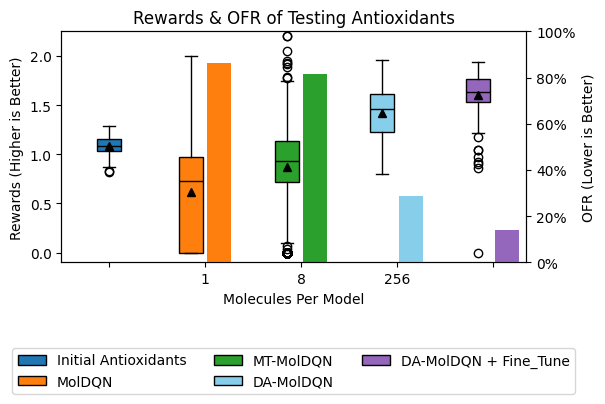

In [33]:
from tools import Results

average_episodes = 1
max_bde = 76
min_ip = 145

exp_path = '../Experiments'
trials = [1000, 1100, '9xxx', '573200_test']
rewards = [Results(f'{exp_path}/trial_{t}.pickle') for t in trials]
initial_rewards = [rewards[1][p] for p in rewards[1].match('128.*_initial_reward')]
initial_rewards = np.array(initial_rewards).flatten()
rs = [initial_rewards]


for r in rewards:
    if '9xxx' in r.path:
        rs.append(np.array([r[p][-average_episodes:] for p in r.match('^9000_rank_[1-7]_rewards$')]).flatten())
    else :
        rs.append(np.array([r[p][-average_episodes:] for p in r.match('.*_rewards')]).flatten())

min_r = 0
max_r = 3
for r in rs:
    # r = np.clip(r, 0, 3)
    mask = (r < min_r) | (r > max_r)
    r[mask] = 0
    print(len(r), np.mean(r))
# print(rs)

# bs = [0.8613, 0.8145, 0.2857, 0.1406]
bs = []
for p, r in zip([1000,1100,9000], rs[1:4]):
    path = f'{exp_path}/filtered/trial_{p}_filtered.csv'
    df = pd.read_csv(path)
    b = len(df.init_smiles.values)
    bs.append(1 - b / len(r))
bs.append(rewards[-1].calc_ofr_legacy())
print(bs)

fig = plt.figure(figsize =(6, 3))
plt.ylim((-0.1, 2.25))

w = 0.25
b1 = plt.boxplot(rs[0:1], positions=[0], showmeans=True, widths=[w],
                 patch_artist=True, #labels = [''],
            boxprops={"facecolor":"C0","edgecolor":"black"},
            medianprops={"color": "k"},
            meanprops={"markerfacecolor":"k","markeredgecolor":"k"}
           )

b2 = plt.boxplot(rs[1:2], positions=[0.85], showmeans=True, widths=[w],
                 patch_artist=True,# labels = ['1'],
            boxprops={"facecolor":"C1","edgecolor":"black"},
            medianprops={"color": "k"},
            meanprops={"markerfacecolor":"k","markeredgecolor":"k"}
           )

b3 = plt.boxplot(rs[2:3], positions=[1.85], showmeans=True, widths=[w],
                 patch_artist=True, #labels = ['8'],
            boxprops={"facecolor":"C2","edgecolor":"black"},
            medianprops={"color": "k"},
            meanprops={"markerfacecolor":"k","markeredgecolor":"k"}
           )
b4 = plt.boxplot(rs[3:4], positions=np.arange(2.85,3.85,1), showmeans=True, widths=[w for _ in np.arange(3, 4)],
                 patch_artist=True,# labels = ['16','32', '64', '128', '256'],
            boxprops={"facecolor":"skyblue","edgecolor":"black"},
            medianprops={"color": "k"},
            meanprops={"markerfacecolor":"k","markeredgecolor":"k"}
           )

b5 = plt.boxplot(rs[4:5], positions=[3.85], showmeans=True, widths=[w],
                 patch_artist=True,# labels = [''],
            boxprops={"facecolor":"C4","edgecolor":"black"},
            medianprops={"color": "k"},
            meanprops={"markerfacecolor":"k","markeredgecolor":"k"}
           )

plt.xticks(range(5), ['', '1', '8', '256',''])


plt.legend([b1["boxes"][0], b2["boxes"][0], b3["boxes"][0], b4["boxes"][0], b5["boxes"][0]], 
           ['Initial Antioxidants','MolDQN', 'MT-MolDQN', 'DA-MolDQN', 'DA-MolDQN + Fine_Tune'], 
           loc='lower center', bbox_to_anchor=(0.5,-0.6),
           ncol=3
          )

plt.xlabel('Molecules Per Model')
plt.ylabel('Rewards (Higher is Better)')

ax2 = plt.twinx()
ax2.set_ylabel('OFR (Lower is Better)')
ax2.set_ylim(0, 1)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y))) 


p2 = ax2.bar(np.arange(1.15,5.15,1), bs, color=['C1','C2','skyblue', 'C4'], width=w)
# plt.bar_label(p2, label_type='edge', padding = 5, fmt='%.0f%%')

ax2.tick_params(axis='y')

plt.title('Rewards & OFR of Testing Antioxidants')
# plt.title('Antioxidant Rewards of Different Models (Higher is Better)')
# plt.xticks(rotation=45)
plt.savefig("../results/Rewards_ofr_anti_test.png", dpi=500, bbox_inches = 'tight')
plt.show()



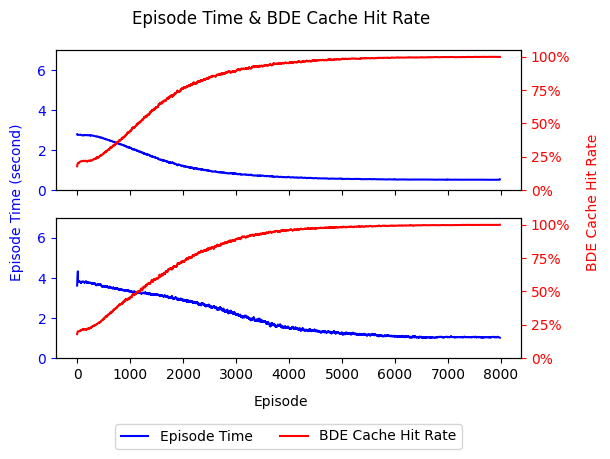

In [35]:
from tools import Results

def movingaverage(interval, window_size = 20):
    window = np.ones(int(window_size))/float(window_size)
    return np.convolve(interval, window, 'valid')



exp_path = '../Experiments'
episodes = 8000
trials = [600, 2200]
results = [Results(f'{exp_path}/trial_{t}.pickle') for t in trials]
episode_time_600, hit_rate_600 = results[0].get_episode_time_legacy(), results[0].get_episode_lru_cache_hit_rate_legacy()
episode_time_2200, hit_rate_2200 = results[1].get_episode_time_legacy(), results[1].get_episode_lru_cache_hit_rate_legacy()
episode_time_600, hit_rate_600 = movingaverage(episode_time_600), movingaverage(hit_rate_600)
episode_time_2200, hit_rate_2200 = movingaverage(episode_time_2200), movingaverage(hit_rate_2200)

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(6,4), sharey=True)

ax12 = ax1.twinx()
p1e, = ax1.plot(episode_time_600, "b-", label = "Episode Time")
p1h, = ax12.plot(hit_rate_600, "r-", label=f"BDE Cache Hit Rate")
ax1.set_ylim(0, 3)
ax12.set_ylim(0, 1.05)
ax1.set_xticklabels([])
ax12.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y))) 
ax1.tick_params(axis='y', colors=p1e.get_color())
ax12.tick_params(axis='y', colors=p1h.get_color())


ax22 = ax2.twinx()
p2e, = ax2.plot(episode_time_2200, "b-", label = "Episode Time")
p2h, = ax22.plot(hit_rate_2200, "r-", label=f"BDE Cache Hit Rate")
ax2.set_ylim(0, 7)
ax22.set_ylim(0, 1.05)
ax22.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y))) 
ax2.tick_params(axis='y', colors=p2e.get_color())
ax22.tick_params(axis='y', colors=p2h.get_color())



fig.text(0.5, 0.00, 'Episode', va = 'center', ha='center')
fig.text(0.06, 0.5, 'Episode Time (second)', va = 'center', ha='center', rotation='vertical', color=p1e.get_color())
fig.text(1.02, 0.5, 'BDE Cache Hit Rate', va = 'center', ha='center', rotation='vertical', color=p1h.get_color())


plt.suptitle('Episode Time & BDE Cache Hit Rate')
plt.legend([p1e, p1h],
           ['Episode Time','BDE Cache Hit Rate'], 
           loc='lower center', bbox_to_anchor=(0.5,-0.7),
           ncol=2
          )

plt.savefig("../results/Episode_Time_Cache_600_2200.png", dpi = 500, bbox_inches = 'tight')
plt.show()

[3.52131061 6.63039338 1.         0.0491224 ] [ 28.1704849  106.08629401   1.           0.78595841]


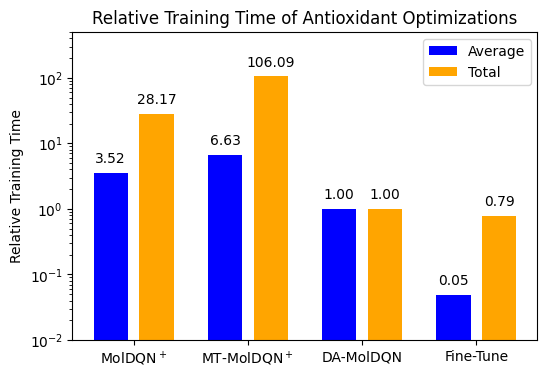

In [36]:
# computation time
from tools import Results
exp_path = '../Experiments'
episodes = 8000
trials = [600, 800, '573_', 573200]
parallel_on_16A100 = [8, 16, 1, 16]
results = [Results(f'{exp_path}/trial_{t}.pickle') for t in trials]
cts, ats = [], []

for r, p in zip(results, parallel_on_16A100):
    ns = r.get_computation_time_legacy()
    ave, _ = np.mean(ns), np.sum(ns)
    cts.append(ave)
    ats.append(ave * p)

cts = np.array([c / cts[2] for c in cts])
ats = np.array([c / ats[2] for c in ats])
print(cts, ats)

width = 0.3
x = np.arange(4)

# texts = ['Individual', 'Parallel', 'General ', 'Fine-Tuned']
texts = [r"MolDQN$^+$", 'MT-MolDQN$^+$', 'DA-MolDQN', 'Fine-Tune']
    # string_labels.append(r"$10^{%02d}$" % (i/10.0))

plt.figure(figsize=(6,4))

plt.axes(yscale = "log")
plt.ylim((0.01, 500))

b1 = plt.bar(x-0.2, cts, width, color='blue')
plt.bar_label(b1, label_type='edge', padding = 5, fmt='%.2f')

b2 = plt.bar(x+0.2, ats, width, color='orange')
plt.bar_label(b2, label_type='edge', padding = 5, fmt='%.2f')


plt.ylabel('Relative Training Time')

# # plt.xticks(rotation=45)
plt.xticks(x, texts)
plt.legend(['Average', 'Total'])
plt.title('Relative Training Time of Antioxidant Optimizations')
plt.savefig("../results/relative_computation_time_new.png", dpi=500)
plt.show()



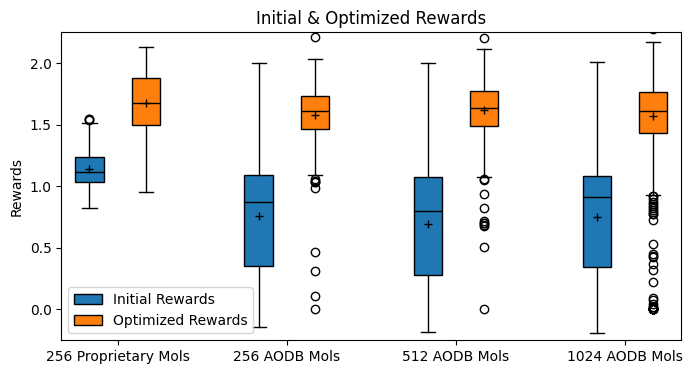

In [41]:
from tools import Results

average_episodes = 1
max_bde = 76
min_ip = 145

min_r = 0
max_r = 3


exp_path = '../Experiments'
trials = ['573_', '1500_', '1501_', '1503_'] 
rewards = [Results(f'{exp_path}/trial_{t}.pickle') for t in trials]
init_rs, rs = [], []
for r in rewards:
    init_rs.append(np.array([r[p] for p in r.match('.*_initial_reward')]).flatten())
    rs.append(np.array([r[p][-average_episodes:] for p in r.match('.*_rewards')]).flatten())
    # print(init_rs[-1].shape, rs[-1].shape)
for r in rs:
    mask = (r < min_r) | (r > max_r)
    r[mask] = 0
# print(init_rs, rs)

x1 = np.arange(1, 12, 3)
x2 = x1 + 1
xt = x1 + 0.5

fig = plt.figure(figsize =(8, 4))
plt.ylim((-0.25, 2.25))
# plt.boxplot([init_rs, irs, prs, grs, frs, mrs], showmeans=True,
#             labels = ['Initial Rewards', 'Independent Models', 'Parallel Models', 'General Model (GM)',
#                       'Fine Tune (FT)', 'Max(GM, FT)'])
b1 = plt.boxplot(init_rs, positions=x1, showmeans=True, patch_artist=True, 
            boxprops={"facecolor":"C0","edgecolor":"black"},
            medianprops={"color": "k"},
            meanprops={"marker":"+","markerfacecolor":"k","markeredgecolor":"k"}
           )
b2 = plt.boxplot(rs, positions=x2, showmeans=True, patch_artist=True, 
            boxprops={"facecolor":"C1","edgecolor":"black"},
            medianprops={"color": "k"},
            meanprops={"marker":"+","markerfacecolor":"k","markeredgecolor":"k"}
           )

plt.ylabel('Rewards')
plt.title('Initial & Optimized Rewards')
plt.xticks(xt, ['256 Proprietary Mols','256 AODB Mols','512 AODB Mols','1024 AODB Mols'])
# plt.xticks(rotation=45)
plt.legend(handles=[b1['boxes'][0], b2['boxes'][0]], labels=['Initial Rewards', 'Optimized Rewards'])
plt.savefig("../results/Compare_Rewards_aodb.png", dpi=500, bbox_inches = 'tight')
plt.show()


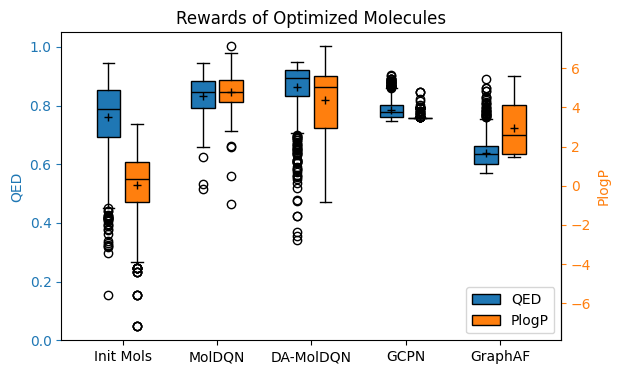

In [42]:
from tools import Results, GNNResults
average_episodes = 1
exp_path = '../Experiments'
trials = ['ZincQEDFT_', 'ZincQEDIND_', 'ZincPlogpFT_', 'ZincPlogPIND_'] 
rewards = [Results(f'{exp_path}/{t}.pickle') for t in trials]
init_qed = rewards[0].get_initial_rewards()['reward']
init_plogp = rewards[2].get_initial_rewards()['reward']
rs = [r.get_rewards()['reward'] for r in rewards]

gcpn_results_path = '../refs/GCPN/results'
graphaf_results_path = '../refs/GraphAF/results'
rgcn_qeds = GNNResults(f'{gcpn_results_path}/RGCN_47000_qed_10epoch.txt').calc_QED()[-1024:]
graphaf_qeds = GNNResults(f'{graphaf_results_path}/GraphAF_6400_qed_2epoch.txt').calc_QED()[-1024:]
rgcn_plogp = GNNResults(f'{gcpn_results_path}/RGCN_18000_plogp_1epoch.txt').calc_PlogP()[-1024:]
graphaf_plogp = GNNResults(f'{graphaf_results_path}/GraphAF_6400_plogp_2epoch.txt').calc_PlogP()[-1024:]

ts_qed =[init_qed,  rs[1], rs[0], rgcn_qeds, graphaf_qeds]
ts_plogp =[init_plogp, rs[3], rs[2], rgcn_plogp, graphaf_plogp]

w = 0.25

fig, host = plt.subplots(figsize = (8, 4))
fig.subplots_adjust(right=0.75)

par1 = host.twinx()

xt = np.arange(1,6,1)
xt_qed = np.arange(0.85,5.85,1)
b_qed = host.boxplot(ts_qed, positions=xt_qed, showmeans=True, widths=[w for _ in np.arange(len(ts_qed))],
                 patch_artist=True, 
            boxprops={"facecolor":"C0","edgecolor":"black"},
            medianprops={"color": "k"},
            meanprops={"marker":"+","markerfacecolor":"k","markeredgecolor":"k"}
           )
xt_plogp = np.arange(1.15,6.15,1)
b_plogp = par1.boxplot(ts_plogp, positions=xt_plogp, showmeans=True, widths=[w for _ in np.arange(len(ts_plogp))],
                 patch_artist=True, 
            boxprops={"facecolor":"C1","edgecolor":"black"},
            medianprops={"color": "k"},
            meanprops={"marker":"+","markerfacecolor":"k","markeredgecolor":"k"}
           )

host.set_ylim(0, 1.05)
    
# par1.set_ylim(0, 1.05)
# par1.set_ylim(-8, 8)

host.set_ylabel("QED")
par1.set_ylabel('PlogP')

for ax in [par1]:
    ax.set_frame_on(True)
    ax.patch.set_visible(False)

    plt.setp(ax.spines.values(), visible=False)
    ax.spines["right"].set_visible(True)
    
host.yaxis.label.set_color("C0")
par1.yaxis.label.set_color("C1")

host.tick_params(axis='y', colors="C0")
par1.tick_params(axis='y', colors="C1")

plt.legend([b_qed["boxes"][0], b_plogp["boxes"][0]], 
           ['QED', 'PlogP'], 
           loc='lower right'
          )

# plt.title('Compare Optimized Molecules with Related Works')
plt.title('Rewards of Optimized Molecules')
plt.xticks(xt, ['Init Mols', 'MolDQN','DA-MolDQN','GCPN', 'GraphAF'])


plt.savefig("../results/Compare_Rewards_QED_PlogP.png", dpi=500, bbox_inches = 'tight')
plt.show()



Molecules: 10,250 (1000 ETKDG attempts each)
Always succeed (p̂=1.0): 2974 (29.01%)
Always fail (p̂=0.0): 177 (1.73%)
  maxAttempts=   1: 92.01% (upper: 92.02%)
  maxAttempts=   2: 94.82% (upper: 94.83%)
  maxAttempts=   3: 95.46% (upper: 95.47%)
  maxAttempts=   5: 95.82% (upper: 95.85%)
  maxAttempts=   7: 95.96% (upper: 95.99%)
  maxAttempts=  10: 96.07% (upper: 96.12%)
  maxAttempts=  20: 96.29% (upper: 96.39%)
  maxAttempts=  50: 96.64% (upper: 96.88%)
  maxAttempts= 100: 96.95% (upper: 97.40%)
  maxAttempts= 300: 97.47% (upper: 98.50%)
  maxAttempts=1000: 97.99% (upper: 99.63%)


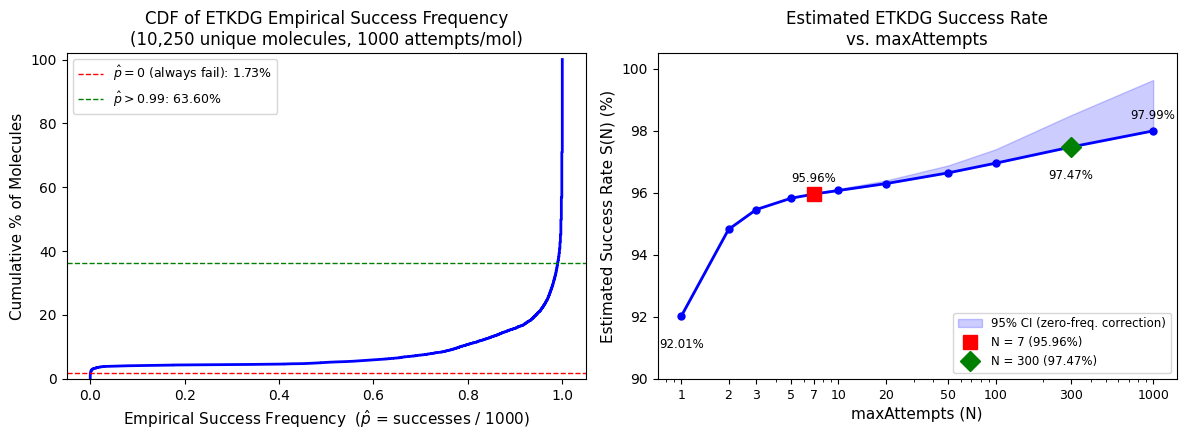

In [17]:
# ETKDG success rate analysis
# Data: 10,250 unique molecules from RL training (trial 33)
# Each molecule tested with EmbedMolecule(maxAttempts=1) x 1000 times
# Empirical success frequency: p̂ = successes / 1000
# Estimated success rate at maxAttempts=N: S(N) = mean[1 - (1-p̂)^N]

import csv

probs = []
with open('../ETKDG_exps/count_33.txt') as f:
    reader = csv.reader(f)
    next(reader)  # skip header: smiles,success,failed
    for row in reader:
        if len(row) >= 3:
            probs.append(int(row[1].strip()) / 1000.0)
probs = np.array(probs)
N = len(probs)
print(f"Molecules: {N:,} (1000 ETKDG attempts each)")
print(f"Always succeed (p̂=1.0): {np.sum(probs==1.0)} ({np.sum(probs==1.0)/N*100:.2f}%)")
print(f"Always fail (p̂=0.0): {np.sum(probs==0.0)} ({np.sum(probs==0.0)/N*100:.2f}%)")

# Upper bound: replace p̂=0 with Rule-of-Three 95% CI upper bound (3/n)
probs_upper = probs.copy()
probs_upper[probs == 0] = 3.0 / 1000

thresholds = [1, 2, 3, 5, 7, 10, 20, 50, 100, 300, 1000]
rates = [np.mean(1 - (1 - probs)**t) * 100 for t in thresholds]
rates_upper = [np.mean(1 - (1 - probs_upper)**t) * 100 for t in thresholds]
for t, r, ru in zip(thresholds, rates, rates_upper):
    print(f"  maxAttempts={t:>4}: {r:.2f}% (upper: {ru:.2f}%)")

# --- Combined figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# ===== Left: CDF of empirical success frequency =====
sorted_p = np.sort(probs)
cdf = np.arange(1, N+1) / N * 100
ax1.plot(sorted_p, cdf, 'b-', linewidth=2)

p0_pct = np.sum(probs == 0) / N * 100
p099_pct = np.sum(probs > 0.99) / N * 100

ax1.axhline(y=p0_pct, color='r', linestyle='--', linewidth=1,
            label=r'$\hat{p}=0$ (always fail): %.2f%%' % p0_pct)
ax1.axhline(y=100 - p099_pct, color='g', linestyle='--', linewidth=1,
            label=r'$\hat{p}>0.99$: %.2f%%' % p099_pct)

ax1.set_xlabel(r'Empirical Success Frequency  ($\hat{p}$ = successes / 1000)', fontsize=11)
ax1.set_ylabel('Cumulative % of Molecules', fontsize=11)
ax1.set_title('CDF of ETKDG Empirical Success Frequency\n(10,250 unique molecules, 1000 attempts/mol)', fontsize=12)
ax1.set_xlim(-0.05, 1.05)
ax1.set_ylim(0, 102)
ax1.legend(fontsize=9)

# ===== Right: Estimated success rate vs maxAttempts =====
ax2.fill_between(thresholds, rates, rates_upper, alpha=0.2, color='b',
                 label='95% CI (zero-freq. correction)')
ax2.plot(thresholds, rates, 'b-o', linewidth=2, markersize=5, zorder=3)

r1 = rates[thresholds.index(1)]
r7 = rates[thresholds.index(7)]
r300 = rates[thresholds.index(300)]
r1000 = rates[thresholds.index(1000)]

ax2.plot(7, r7, 'rs', markersize=10, zorder=4, label=f'N = 7 ({r7:.2f}%)')
ax2.plot(300, r300, 'gD', markersize=10, zorder=4, label=f'N = 300 ({r300:.2f}%)')

ax2.text(1, r1 - 0.7, f'{r1:.2f}%', ha='center', va='top', fontsize=8.5)
ax2.text(7, r7 + 0.3, f'{r7:.2f}%', ha='center', va='bottom', fontsize=8.5)
ax2.text(300, r300 - 0.7, f'{r300:.2f}%', ha='center', va='top', fontsize=8.5)
ax2.text(1000, r1000 + 0.3, f'{r1000:.2f}%', ha='center', va='bottom', fontsize=8.5)

ax2.set_xscale('log')
ax2.set_xticks(thresholds)
ax2.set_xticklabels([str(t) for t in thresholds], fontsize=9)
ax2.set_ylim(90, 100.5)
ax2.set_xlabel('maxAttempts (N)', fontsize=11)
ax2.set_ylabel('Estimated Success Rate S(N) (%)', fontsize=11)
ax2.set_title('Estimated ETKDG Success Rate\nvs. maxAttempts', fontsize=12)
ax2.legend(fontsize=8.5, loc='lower right')

plt.tight_layout()
plt.savefig("../paper/Figures/etkdg_analysis_combined.png", dpi=500, bbox_inches='tight')
plt.show()

Molecules: 163
            index      ml_bde       ml_ip     dft_bde      dft_ip
count  163.000000  163.000000  163.000000  163.000000  163.000000
mean    81.000000   68.188344  175.660613   71.098098  181.696871
std     47.198164    3.148834   12.798914    6.375502   11.560850
min      0.000000   59.150000  146.280000   58.990000  145.320000
25%     40.500000   66.320000  168.510000   66.480000  175.235000
50%     81.000000   67.190000  174.900000   71.400000  182.020000
75%    121.500000   69.965000  183.065000   75.415000  188.440000
max    162.000000   75.870000  207.080000   94.000000  210.630000

BDE:
  Pearson r = 0.248 (p = 1.43e-03)
  Spearman ρ = 0.204 (p = 8.90e-03)
  MAE = 5.50 kcal/mol
  Bias (DFT-ML) = +2.91 kcal/mol
  RMSE = 6.99 kcal/mol
  Linear fit: y = 0.502x + 36.9

IP:
  Pearson r = 0.734 (p = 6.70e-29)
  Spearman ρ = 0.691 (p = 1.91e-24)
  MAE = 8.49 kcal/mol
  Bias (DFT-ML) = +6.04 kcal/mol
  RMSE = 10.77 kcal/mol
  Linear fit: y = 0.663x + 65.2



Saved to results/dft_validation_scatter.png and paper/Figures/


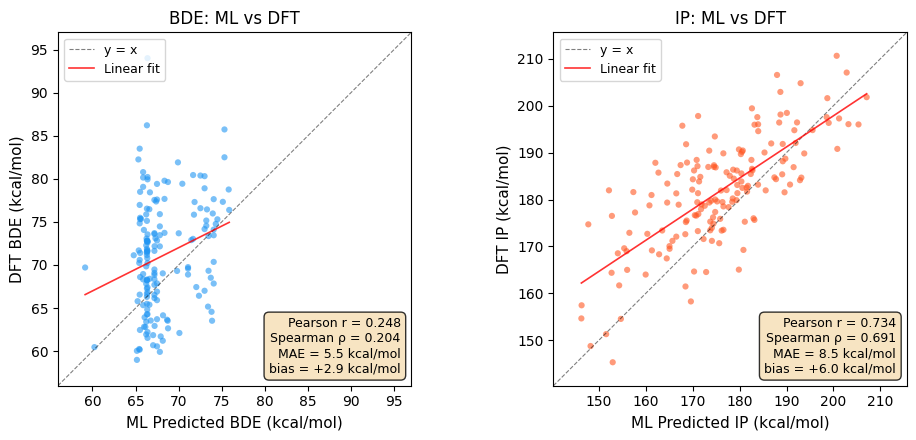

In [3]:
# DFT Validation: Scatter plots of ML vs DFT for BDE and IP
# 163 molecules, gas-phase B3LYP/6-311++G(d,p), vertical IP, min-BDE with Hessian

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy import stats

df = pd.read_csv('../dft/public/dft_validation.csv')
print(f"Molecules: {len(df)}")
print(df.describe())

# --- Compute statistics ---
def calc_stats(x, y, label):
    r, p = stats.pearsonr(x, y)
    rho, p_rho = stats.spearmanr(x, y)
    mae = np.mean(np.abs(y - x))
    bias = np.mean(y - x)
    rmse = np.sqrt(np.mean((y - x)**2))
    slope, intercept, _, _, _ = stats.linregress(x, y)
    print(f"\n{label}:")
    print(f"  Pearson r = {r:.3f} (p = {p:.2e})")
    print(f"  Spearman ρ = {rho:.3f} (p = {p_rho:.2e})")
    print(f"  MAE = {mae:.2f} kcal/mol")
    print(f"  Bias (DFT-ML) = {bias:+.2f} kcal/mol")
    print(f"  RMSE = {rmse:.2f} kcal/mol")
    print(f"  Linear fit: y = {slope:.3f}x + {intercept:.1f}")
    return r, rho, mae, bias, slope, intercept

r_bde, rho_bde, mae_bde, bias_bde, sl_bde, ic_bde = calc_stats(df.ml_bde, df.dft_bde, "BDE")
r_ip, rho_ip, mae_ip, bias_ip, sl_ip, ic_ip = calc_stats(df.ml_ip, df.dft_ip, "IP")

# --- Figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))

# ===== Left: BDE =====
ax1.scatter(df.ml_bde, df.dft_bde, s=20, alpha=0.6, c='#2196F3', edgecolors='none')

# Perfect agreement line
bde_lo = min(df.ml_bde.min(), df.dft_bde.min()) - 3
bde_hi = max(df.ml_bde.max(), df.dft_bde.max()) + 3
ax1.plot([bde_lo, bde_hi], [bde_lo, bde_hi], 'k--', linewidth=0.8, alpha=0.5, label='y = x')

# Regression line
x_fit = np.linspace(df.ml_bde.min(), df.ml_bde.max(), 100)
ax1.plot(x_fit, sl_bde * x_fit + ic_bde, 'r-', linewidth=1.2, alpha=0.8, label='Linear fit')

ax1.set_xlabel('ML Predicted BDE (kcal/mol)', fontsize=11)
ax1.set_ylabel('DFT BDE (kcal/mol)', fontsize=11)
ax1.set_title('BDE: ML vs DFT', fontsize=12)
ax1.set_xlim(bde_lo, bde_hi)
ax1.set_ylim(bde_lo, bde_hi)
ax1.set_aspect('equal')
ax1.xaxis.set_major_locator(MultipleLocator(5))
ax1.yaxis.set_major_locator(MultipleLocator(5))
ax1.legend(fontsize=9, loc='upper left')

# Stats text box
stats_text = (f'Pearson r = {r_bde:.3f}\n'
              f'Spearman ρ = {rho_bde:.3f}\n'
              f'MAE = {mae_bde:.1f} kcal/mol\n'
              f'bias = {bias_bde:+.1f} kcal/mol')
ax1.text(0.97, 0.03, stats_text, transform=ax1.transAxes, fontsize=9,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='wheat', alpha=0.8))

# ===== Right: IP =====
ax2.scatter(df.ml_ip, df.dft_ip, s=20, alpha=0.6, c='#FF5722', edgecolors='none')

# Perfect agreement line
ip_lo = min(df.ml_ip.min(), df.dft_ip.min()) - 5
ip_hi = max(df.ml_ip.max(), df.dft_ip.max()) + 5
ax2.plot([ip_lo, ip_hi], [ip_lo, ip_hi], 'k--', linewidth=0.8, alpha=0.5, label='y = x')

# Regression line
x_fit = np.linspace(df.ml_ip.min(), df.ml_ip.max(), 100)
ax2.plot(x_fit, sl_ip * x_fit + ic_ip, 'r-', linewidth=1.2, alpha=0.8, label='Linear fit')

ax2.set_xlabel('ML Predicted IP (kcal/mol)', fontsize=11)
ax2.set_ylabel('DFT IP (kcal/mol)', fontsize=11)
ax2.set_title('IP: ML vs DFT', fontsize=12)
ax2.set_xlim(ip_lo, ip_hi)
ax2.set_ylim(ip_lo, ip_hi)
ax2.set_aspect('equal')
ax2.xaxis.set_major_locator(MultipleLocator(10))
ax2.yaxis.set_major_locator(MultipleLocator(10))
ax2.legend(fontsize=9, loc='upper left')

stats_text = (f'Pearson r = {r_ip:.3f}\n'
              f'Spearman ρ = {rho_ip:.3f}\n'
              f'MAE = {mae_ip:.1f} kcal/mol\n'
              f'bias = {bias_ip:+.1f} kcal/mol')
ax2.text(0.97, 0.03, stats_text, transform=ax2.transAxes, fontsize=9,
         verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig("../results/dft_validation_scatter.png", dpi=500, bbox_inches='tight')
plt.savefig("../paper/Figures/dft_validation_scatter.png", dpi=500, bbox_inches='tight')
print("\nSaved to results/dft_validation_scatter.png and paper/Figures/")
plt.show()

Initial: 242 unique, in target: 15 (6%)
Optimized: 177 unique, in target: 177 (100%)
Saved to results/ and paper/Figures/


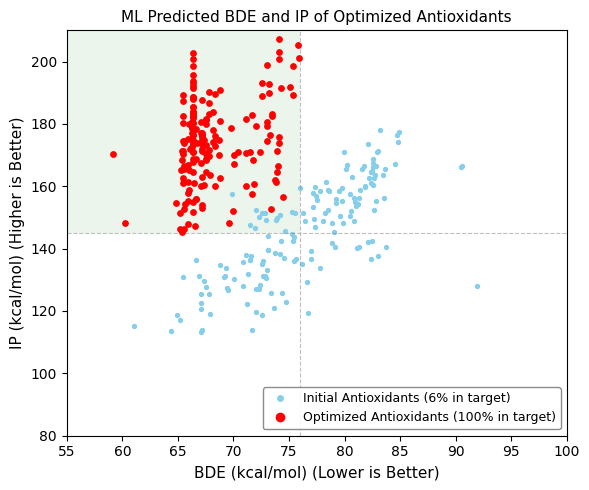

In [15]:
# Figure 10 (ML): Predicted BDE and IP — Initial vs Optimized Antioxidants
# Reproduces paper/Figures/Compare_GM_573_BDE_IP.png with unified style + target zone
# init_bde/init_ip are DFT properties of the proprietary antioxidant dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

df = pd.read_csv('../Data/trial_573200_filtered.csv')

# Deduplicate optimized molecules
seen = set()
pbde_g, pip_g = [], []
for s, b, p in zip(df.generated_smiles, df.predicted_bde, df.predicted_ip):
    if s not in seen:
        seen.add(s)
        pbde_g.append(b)
        pip_g.append(p)

# Initial antioxidants (unique)
seen_init = set()
pbde_i, pip_i = [], []
for s, b, p in zip(df.init_smiles, df.init_bde, df.init_ip):
    if s not in seen_init:
        seen_init.add(s)
        pbde_i.append(b)
        pip_i.append(p)
pbde_i, pip_i = np.array(pbde_i), np.array(pip_i)
pbde_g, pip_g = np.array(pbde_g), np.array(pip_g)

# Target zone stats
n_init_target = ((pbde_i < 76) & (pip_i > 145)).sum()
n_opt_target = ((pbde_g < 76) & (pip_g > 145)).sum()
pct_init = n_init_target / len(pbde_i) * 100
pct_opt = n_opt_target / len(pbde_g) * 100
print(f"Initial: {len(pbde_i)} unique, in target: {n_init_target} ({pct_init:.0f}%)")
print(f"Optimized: {len(pbde_g)} unique, in target: {n_opt_target} ({pct_opt:.0f}%)")

fig, ax = plt.subplots(figsize=(6, 5))

# Target zone
ax.set_xlim(55, 100)
ax.set_ylim(80, 210)
target = Rectangle((55, 145), 76 - 55, 210 - 145, alpha=0.08, facecolor='green', zorder=0)
ax.add_patch(target)
ax.axvline(x=76, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(y=145, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# Scatter
ax.scatter(pbde_i, pip_i, color='skyblue', s=8, zorder=1)
ax.scatter(pbde_g, pip_g, color='red', s=15, zorder=2)

ax.set_xlabel('BDE (kcal/mol) (Lower is Better)', fontsize=11)
ax.set_ylabel('IP (kcal/mol) (Higher is Better)', fontsize=11)
ax.set_title('ML Predicted BDE and IP of Optimized Antioxidants', fontsize=11)

# Combined legend + stats in lower right
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='skyblue', markersize=6,
           label=f'Initial Antioxidants ({pct_init:.0f}% in target)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8,
           label=f'Optimized Antioxidants ({pct_opt:.0f}% in target)'),
]
ax.legend(handles=legend_handles, fontsize=9, loc='lower right',
          framealpha=0.9, edgecolor='gray')

plt.tight_layout()
plt.savefig("../results/Compare_GM_573_BDE_IP.png", dpi=500, bbox_inches='tight')
plt.savefig("../paper/Figures/Compare_GM_573_BDE_IP.png", dpi=500, bbox_inches='tight')
print("Saved to results/ and paper/Figures/")
plt.show()

Initial: 242 unique, in target: 15 (6%)
Optimized: 163 unique, in target: 127 (78%)
Saved to results/ and paper/Figures/


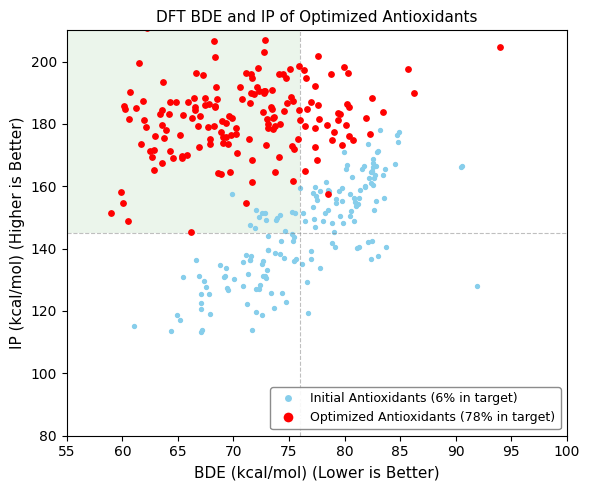

In [16]:
# DFT Validation: DFT BDE and IP — Initial vs Optimized Antioxidants
# Same style as ML plot above, but using DFT-computed properties for optimized molecules
# init_bde/init_ip = DFT (from proprietary dataset), dft_bde/dft_ip = our GPU4PySCF results

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

filtered = pd.read_csv('../Data/trial_573200_filtered.csv')
dft = pd.read_csv('../dft/public/dft_validation.csv')

# All unique initial antioxidants (same set as ML plot)
init_dedup = filtered.drop_duplicates(subset='init_smiles')

# Optimized molecules with DFT results (deduplicated)
merged = filtered.merge(dft, left_on='generated_smiles', right_on='smiles', how='inner')
opt_dedup = merged.drop_duplicates(subset='generated_smiles')

n_init_target = ((init_dedup.init_bde < 76) & (init_dedup.init_ip > 145)).sum()
n_opt_target = ((opt_dedup.dft_bde < 76) & (opt_dedup.dft_ip > 145)).sum()
pct_init = n_init_target / len(init_dedup) * 100
pct_opt = n_opt_target / len(opt_dedup) * 100
print(f"Initial: {len(init_dedup)} unique, in target: {n_init_target} ({pct_init:.0f}%)")
print(f"Optimized: {len(opt_dedup)} unique, in target: {n_opt_target} ({pct_opt:.0f}%)")

fig, ax = plt.subplots(figsize=(6, 5))

# Target zone
ax.set_xlim(55, 100)
ax.set_ylim(80, 210)
target = Rectangle((55, 145), 76 - 55, 210 - 145, alpha=0.08, facecolor='green', zorder=0)
ax.add_patch(target)
ax.axvline(x=76, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(y=145, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# Scatter — same style as ML plot
ax.scatter(init_dedup.init_bde, init_dedup.init_ip, color='skyblue', s=8, zorder=1)
ax.scatter(opt_dedup.dft_bde, opt_dedup.dft_ip, color='red', s=15, zorder=2)

ax.set_xlabel('BDE (kcal/mol) (Lower is Better)', fontsize=11)
ax.set_ylabel('IP (kcal/mol) (Higher is Better)', fontsize=11)
ax.set_title('DFT BDE and IP of Optimized Antioxidants', fontsize=11)

# Combined legend + stats in lower right
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='skyblue', markersize=6,
           label=f'Initial Antioxidants ({pct_init:.0f}% in target)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8,
           label=f'Optimized Antioxidants ({pct_opt:.0f}% in target)'),
]
ax.legend(handles=legend_handles, fontsize=9, loc='lower right',
          framealpha=0.9, edgecolor='gray')

plt.tight_layout()
plt.savefig("../results/dft_init_vs_optimized.png", dpi=500, bbox_inches='tight')
plt.savefig("../paper/Figures/dft_init_vs_optimized.png", dpi=500, bbox_inches='tight')
print("Saved to results/ and paper/Figures/")
plt.show()

In [7]:
# Diversity Analysis for R1-7 Reviewer Response
# Computes quantitative diversity metrics across DA-MolDQN configs (1-256 mols)
# and reference datasets (AODB, ChEMBL, ZINC 10k)

import numpy as np
import matplotlib.pyplot as plt
from diversity import load_all_path, load_ref

EXPERIMENT = "diversity_qed"
TRIAL_BASE = 4000
ALL_CONFIGS = [1, 2, 4, 8, 16, 32, 64, 128, 256]
EXP_DIR = "../Experiments"
DATA_DIR = "../Data"

# Load all datasets
datasets, total_counts = {}, {}
for nmol in ALL_CONFIGS:
    smi, total = load_all_path(EXP_DIR, EXPERIMENT, TRIAL_BASE + nmol)
    if smi:
        name = f"{nmol}_mols"
        datasets[name], total_counts[name] = smi, total
        print(f"{name}: {total} total, {len(smi)} unique")

for ref in ["AODB", "ChEMBL", "ZINC"]:
    smi, total = load_ref(DATA_DIR, ref)
    if smi:
        datasets[ref], total_counts[ref] = smi, total
        print(f"{ref}: {total} total, {len(smi)} unique")

print(f"\nLoaded {len(datasets)} datasets")

1_mols: 5250 total, 1084 unique
2_mols: 10500 total, 2187 unique
4_mols: 21000 total, 4128 unique
8_mols: 42000 total, 8764 unique
16_mols: 84000 total, 21163 unique
32_mols: 100800 total, 39694 unique
64_mols: 336000 total, 88972 unique


128_mols: 672000 total, 169254 unique
256_mols: 1344000 total, 383023 unique


[20:48:56] WARNING: not removing hydrogen atom without neighbors


AODB: 56587 total, 56359 unique
ChEMBL: 10000 total, 10000 unique
ZINC: 10001 total, 10001 unique

Loaded 12 datasets


In [8]:
# Compute all diversity metrics (cached to disk)
from diversity import compute_all_metrics

CACHE_PATH = "../Experiments/.diversity_cache.pickle"
fps_dict, results = compute_all_metrics(datasets, total_counts, cache_path=CACHE_PATH)
names = list(datasets.keys())

Computing fingerprints...
  1_mols: 1084 valid FPs
  2_mols: 2187 valid FPs
  4_mols: 4128 valid FPs
  8_mols: 8764 valid FPs
  16_mols: 21163 valid FPs
  32_mols: 39694 valid FPs
  64_mols: 88972 valid FPs
  128_mols: 169254 valid FPs
  256_mols: 383023 valid FPs


[20:50:49] WARNING: not removing hydrogen atom without neighbors


  AODB: 56359 valid FPs
  ChEMBL: 10000 valid FPs
  ZINC: 10001 valid FPs
  1_mols: done
  2_mols: done
  4_mols: done
  8_mols: done
  16_mols: done
  32_mols: done
  64_mols: done
  128_mols: done
  256_mols: done


[21:04:14] WARNING: not removing hydrogen atom without neighbors
[21:04:25] WARNING: not removing hydrogen atom without neighbors


  AODB: done
  ChEMBL: done
  ZINC: done

Dataset           Total     Unique  Scaffolds  ScaffDiv  IntDiv  Shannon  ScaffH_n  BRICS_H
-------------------------------------------------------------------------------------------
1_mols            5,250      1,084        206     0.190   0.831   0.1654    0.7832      7.2
2_mols           10,500      2,187        504     0.230   0.876   0.1831    0.8652      7.9
4_mols           21,000      4,128      1,038     0.251   0.902   0.1781    0.8724      8.9
8_mols           42,000      8,764      2,294     0.262   0.907   0.1803    0.8893      9.5
16_mols          84,000     21,163      5,089     0.240   0.904   0.1977    0.8946      9.7
32_mols         100,800     39,694     10,800     0.272   0.906   0.1903    0.9180     10.0
64_mols         336,000     88,972     20,927     0.235   0.909   0.1923    0.9069     10.3
128_mols        672,000    169,254     46,302     0.274   0.910   0.1907    0.9256     10.3
256_mols      1,344,000    383,023    

Saved Figure A: diversity_vs_nmols.png


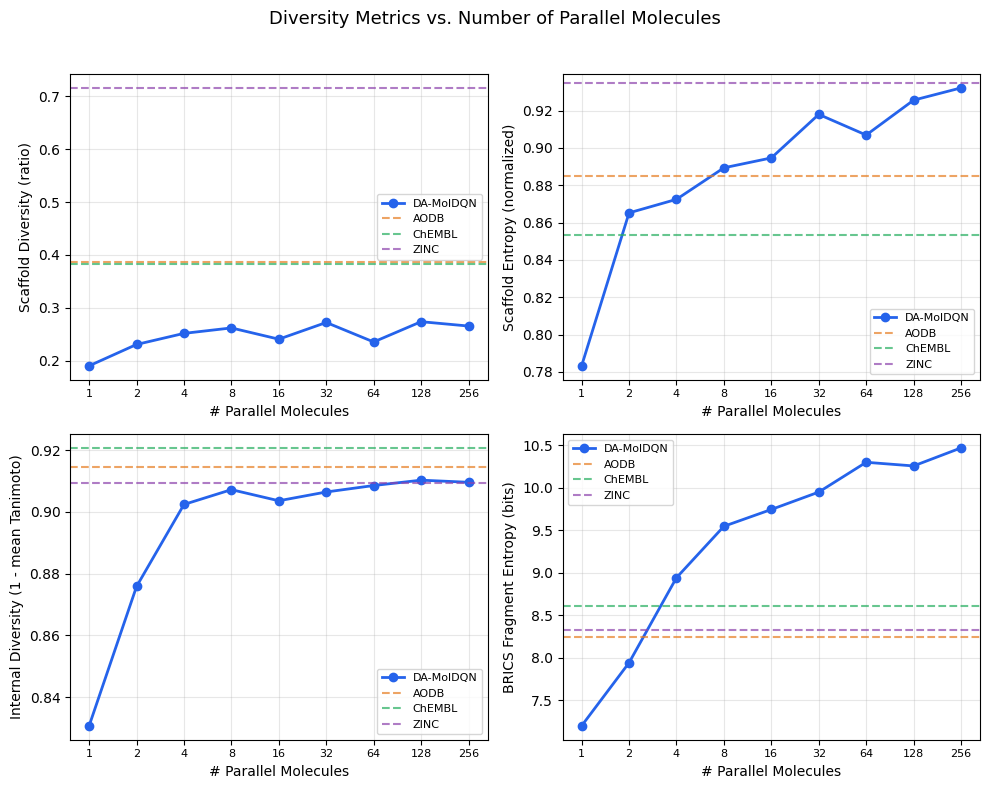

Saved Figure B: counts_vs_nmols.png


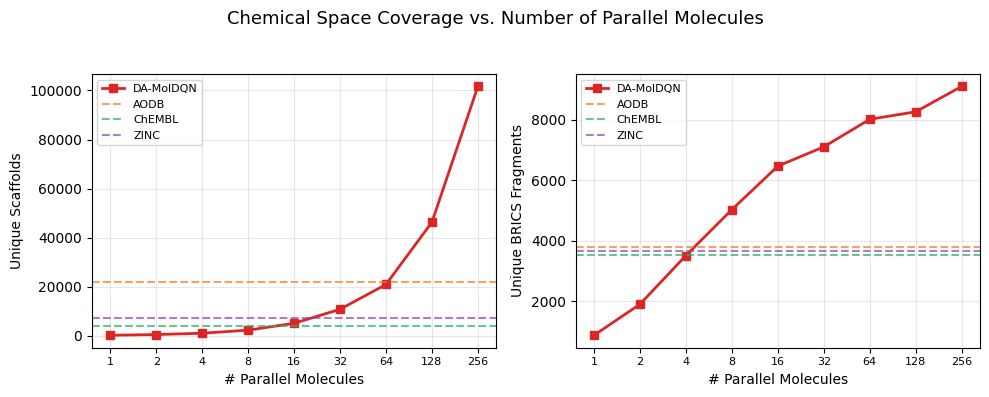

In [9]:
# Figure A: 2x2 Diversity Metrics vs #mols (log scale)
# Figure B: Absolute counts vs #mols

config_names = [n for n in names if n.endswith("_mols")]
ref_names = [n for n in names if not n.endswith("_mols")]
x_vals = [int(n.split("_")[0]) for n in config_names]

ref_colors = {"AODB": "#e67e22", "ChEMBL": "#27ae60", "ZINC": "#8e44ad"}

# --- Figure A: 2x2 diversity metrics ---
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Diversity Metrics vs. Number of Parallel Molecules", fontsize=13)

metric_specs = [
    ("Scaffold_ratio", "Scaffold Diversity (ratio)", axes[0, 0]),
    ("Scaffold_H_norm", "Scaffold Entropy (normalized)", axes[0, 1]),
    ("IntDiv", "Internal Diversity (1 - mean Tanimoto)", axes[1, 0]),
    ("Frag_H", "BRICS Fragment Entropy (bits)", axes[1, 1]),
]

for metric_key, ylabel, ax in metric_specs:
    y_vals = [results[n][metric_key] for n in config_names]
    ax.plot(x_vals, y_vals, "o-", color="#2563eb", linewidth=2, markersize=6, label="DA-MolDQN")
    ax.set_xlabel("# Parallel Molecules")
    ax.set_ylabel(ylabel)
    ax.set_xscale("log", base=2)
    ax.set_xticks(x_vals)
    ax.set_xticklabels([str(v) for v in x_vals], fontsize=8)
    for ref in ref_names:
        ax.axhline(results[ref][metric_key], linestyle="--", linewidth=1.5,
                   color=ref_colors.get(ref, "gray"), label=ref, alpha=0.7)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig("../results/diversity_vs_nmols.png", dpi=500, bbox_inches="tight")
fig.savefig("../paper/Figures/diversity_vs_nmols.png", dpi=500, bbox_inches="tight")
print("Saved Figure A: diversity_vs_nmols.png")
plt.show()

# --- Figure B: Absolute counts ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Chemical Space Coverage vs. Number of Parallel Molecules", fontsize=13)

count_specs = [
    ("N_scaffolds", "Unique Scaffolds", axes[0]),
    ("N_fragments", "Unique BRICS Fragments", axes[1]),
]

for metric_key, ylabel, ax in count_specs:
    y_vals = [results[n][metric_key] for n in config_names]
    ax.plot(x_vals, y_vals, "s-", color="#dc2626", linewidth=2, markersize=6, label="DA-MolDQN")
    ax.set_xlabel("# Parallel Molecules")
    ax.set_ylabel(ylabel)
    ax.set_xscale("log", base=2)
    ax.set_xticks(x_vals)
    ax.set_xticklabels([str(v) for v in x_vals], fontsize=8)
    for ref in ref_names:
        ax.axhline(results[ref][metric_key], linestyle="--", linewidth=1.5,
                   color=ref_colors.get(ref, "gray"), label=ref, alpha=0.7)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig("../results/counts_vs_nmols.png", dpi=500, bbox_inches="tight")
fig.savefig("../paper/Figures/counts_vs_nmols.png", dpi=500, bbox_inches="tight")
print("Saved Figure B: counts_vs_nmols.png")
plt.show()